In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
predictors = ['oDM', 'acog_PEgHTN', 'ChronHTN']
columns = ['CMAE08', 'CMAE14', 'PublicID']
df = pd.read_csv('pregnancy_outcomes.csv', usecols=predictors + ['PublicID'])
df_temp = pd.read_csv('CMA.csv', usecols=columns)
df = pd.merge(df, df_temp, on='PublicID', how='inner')
df_out = pd.read_csv('Outcome.csv',usecols=['PublicID','MH_outcome'])
df_out = df_out[df_out != 'D']
df_out = df_out.dropna()
# (df_out == 'S').sum()
df = pd.merge(df, df_out, on='PublicID', how='inner')

In [3]:
# df = df[df != 'D']
# df['CBAA04a'] = df['CBAA04a'].astype(float)
# df['CBAA04b'] = df['CBAA04b'].astype(float)

In [4]:
df = df.dropna()

In [5]:

# Assuming 'df' is your DataFrame
for column in df.columns:
    print(f"Value counts for {column}:")
    print(df[column].value_counts(dropna=False))  # Setting dropna=False includes NaN value counts
    print("\n")  # Adds a newline for better readability


Value counts for PublicID:
PublicID
00004O    1
11587W    1
11524A    1
11522E    1
11521G    1
         ..
05707B    1
05706D    1
05702L    1
05701N    1
17354P    1
Name: count, Length: 7726, dtype: int64


Value counts for oDM:
oDM
3.0    7304
2.0     319
1.0     103
Name: count, dtype: int64


Value counts for ChronHTN:
ChronHTN
2.0    7535
1.0     191
Name: count, dtype: int64


Value counts for acog_PEgHTN:
acog_PEgHTN
7.0    5951
6.0     684
5.0     421
4.0     318
3.0     305
2.0      44
1.0       3
Name: count, dtype: int64


Value counts for CMAE08:
CMAE08
2.0    7528
1.0     198
Name: count, dtype: int64


Value counts for CMAE14:
CMAE14
2.0    7726
Name: count, dtype: int64


Value counts for MH_outcome:
MH_outcome
0    4583
1    3143
Name: count, dtype: int64




In [6]:
df.to_csv('maternal_df.csv', index=False)

In [8]:
# df['CBAA04a'] = df['CBAA04a'].apply(lambda x: 0 if x < 7 else 1)
# df['CBAA04b'] = df['CBAA04b'].apply(lambda x: 0 if x < 7 else 1)

In [26]:
y = df['MH_outcome']
X = df.drop(['PublicID','MH_outcome'], axis=1)


In [39]:
# y = df_out.drop(['V4AH01','Birth_Weight_Category','CBAA04a','CBAA04b','Birth_Type','Preterm_Birth_Category'],axis=1)

In [29]:
# X['CMAE14'].value_counts()
# y = df_out
df_maternal = df
%store df_maternal

Stored 'df_maternal' (DataFrame)


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

model = LogisticRegression(solver='liblinear')

model.fit(X_train, y_train)

# model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef}")

Model Coefficients:
oDM: -0.043983323604756736
ChronHTN: -0.565184886381108
acog_PEgHTN: -0.016035757331985163
CMAE08: -0.24911616375342924
CMAE14: 0.7359565954221771


In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Evaluation Metrics:
Accuracy: 0.5763
Precision: 0.5541
Recall: 0.5763
F1-score: 0.5199
ROC AUC: 0.5263


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [500, 600, 700],
    'max_depth': [ 20, 18,15],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

# Create a random forest classifier
rf = RandomForestClassifier()

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)


In [15]:
rf_model = RandomForestClassifier(n_estimators=best_params['n_estimators'],
                                  max_depth=best_params['max_depth'],
                                  min_samples_split=best_params['min_samples_split'],
                                  min_samples_leaf=best_params['min_samples_leaf'],
                                  random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# Get feature importances and create a DataFrame with feature names and their importance scores
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})

# Select the top k important features and store them in selected_features
k = 6  # Number of top features to select
selected_features = feature_importance_df.nlargest(k, 'Importance')['Feature']

print("Top Important Features:")
print(feature_importance_df.head(10))  # Change 10 to the number of top features you want to see

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
# roc_auc = roc_auc_score(y_test, y_pred)

# conf_matrix = confusion_matrix(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
# print(f"ROC AUC: {roc_auc:.4f}")
# print("Confusion Matrix:")
# print(conf_matrix)

C:\Users\91799\AppData\Local\Temp\ipykernel_16764\302653683.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf_model.fit(X_train, y_train)


Top Important Features:
       Feature  Importance
0          oDM    0.267302
1     ChronHTN    0.200417
2  acog_PEgHTN    0.353256
3       CMAE08    0.179025
4       CMAE14    0.000000
Evaluation Metrics:
Accuracy: 0.5666
Precision: 0.5365
Recall: 0.5666
F1-score: 0.5043


In [45]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

C:\Users\91799\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Evaluation Metrics:
Accuracy: 0.6005
Precision: 0.3606
Recall: 0.6005
F1-score: 0.4506
Confusion Matrix:
[[508   0]
 [338   0]]


C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [32]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


# Define the XGBoost model
model = XGBClassifier()

# Define hyperparameters to search
param_grid = {
    'learning_rate': [0.01, 0.05, 0.001],
    'n_estimators': [100, 80, 60],
    'max_depth': [7, 4, 6],
    'subsample': [0.8, 0.7, 0.5],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='roc_auc')
grid_result = grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Hyperparameters: ", grid_result.best_params_)
print("Best ROC AUC Score: ", grid_result.best_score_)

# Use the best model
best_model = grid_result.best_estimator_
 
y_pred_prob = best_model.predict_proba(X_test)
# y_pred = np.where(y_pred_prob[:, 1] >= 0.5, 1, 0)

y_pred = [1 if prob[1] >= 0.4 else 0 for prob in y_pred_prob]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 367, in _score
    raise ValueError("{0} format is not supported".format(y_type))
ValueError: multiclass format is not supported

  warnings.warn(
C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
 

C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 367, in _score
    raise ValueError("{0} format is not supported".format(y_type))
ValueError: multiclass format is not supported

  warnings.warn(
C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
 

C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 367, in _score
    raise ValueError("{0} format is not supported".format(y_type))
ValueError: multiclass format is not supported

  warnings.warn(
C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
 

C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 367, in _score
    raise ValueError("{0} format is not supported".format(y_type))
ValueError: multiclass format is not supported

  warnings.warn(
C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
 

C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 367, in _score
    raise ValueError("{0} format is not supported".format(y_type))
ValueError: multiclass format is not supported

  warnings.warn(
C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
 

...

C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 367, in _score
    raise ValueError("{0} format is not supported".format(y_type))
ValueError: multiclass format is not supported

  warnings.warn(
C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
 

C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 367, in _score
    raise ValueError("{0} format is not supported".format(y_type))
ValueError: multiclass format is not supported

  warnings.warn(
C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
 

C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 367, in _score
    raise ValueError("{0} format is not supported".format(y_type))
ValueError: multiclass format is not supported

  warnings.warn(
C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
 

C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 367, in _score
    raise ValueError("{0} format is not supported".format(y_type))
ValueError: multiclass format is not supported

  warnings.warn(
C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
 

KeyboardInterrupt: 

In [37]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the XGBoost model
model = XGBClassifier(objective='multi:softprob', num_class=3)  # num_classes is the number of classes in your multiclass problem

# Define hyperparameters to search
param_grid = {
    'learning_rate': [0.01, 0.05, 0.001],
    'n_estimators': [90, 80, 70],
    'max_depth': [3, 4, 5],
    'subsample': [0.3, 0.4, 0.5],
    'colsample_bytree': [0.8, 0.7, 0.6]
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_log_loss')
grid_result = grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Hyperparameters: ", grid_result.best_params_)
print("Best Negative Log Loss Score: ", grid_result.best_score_)

# Use the best model
best_model = grid_result.best_estimator_

y_pred_prob = best_model.predict_proba(X_test)
y_pred = y_pred_prob.argmax(axis=1)  # Get the index of the class with the highest probability for each instance

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
# roc_auc = roc_auc_score(y_test, y_pred, average='weighted', multi_class='ovo')  # 'ovo' for multiclass ROC AUC

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
# print(f"ROC AUC: {roc_auc:.4f}")


Best Hyperparameters:  {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 80, 'subsample': 0.3}
Best Negative Log Loss Score:  -0.9045115434494635
Evaluation Metrics:
Accuracy: 0.6418
Precision: 0.4142
Recall: 0.6418
F1-score: 0.5035


In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

# Create a RandomForestRegressor instance
rf_regressor = RandomForestRegressor(random_state=123)

# Fit the model
rf_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

C:\Users\91799\AppData\Local\Temp\ipykernel_20636\3866221065.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf_regressor.fit(X_train, y_train)


Mean Squared Error: 0.2391464739087077
Mean Absolute Error: 0.4754030149818925
R-squared: 0.003162665284182964


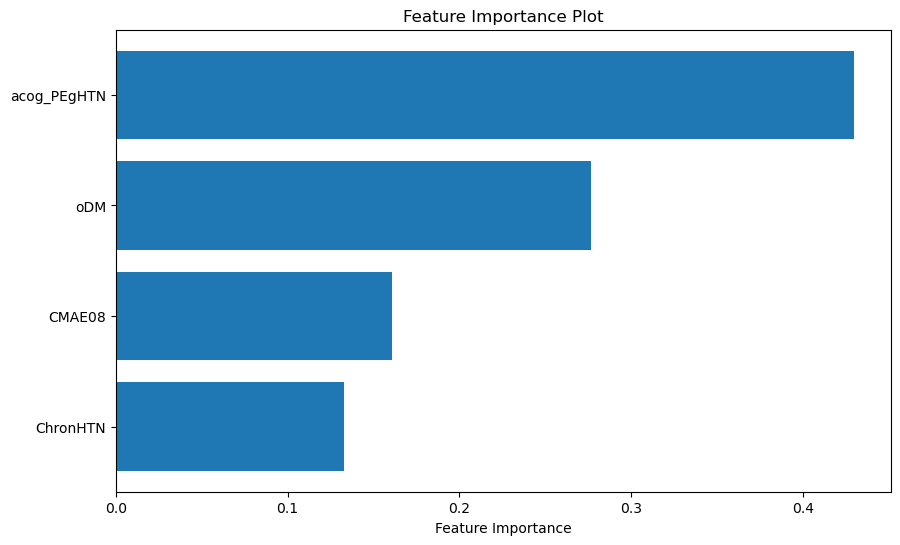

In [49]:
import matplotlib.pyplot as plt

feature_importance = rf_regressor.feature_importances_
feature_names = X_train.columns

# Sort feature importance in descending order
sorted_feature_importance, sorted_feature_names = zip(*sorted(zip(feature_importance, feature_names), reverse=True))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_feature_names)), sorted_feature_importance, align='center')
plt.yticks(range(len(sorted_feature_names)), sorted_feature_names)
plt.xlabel('Feature Importance')
plt.title('Feature Importance Plot')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important feature at the top
plt.show()

In [50]:
# Assuming you already have the feature_importance and feature_names
for feature, importance in zip(feature_names, feature_importance):
    print(f"{feature}: {importance:.4f}")


oDM: 0.2769
ChronHTN: 0.1328
acog_PEgHTN: 0.4297
CMAE08: 0.1606
